# SmolVLM ScienceQA: Minimal End-to-End Pipeline

**目标**: 跑通最小闭环，看实际表现，再优化。

**Pipeline**:
1. Setup + 从 Kaggle 拉数据 (Colab + kaggle.json)
2. Data loading + prompt building (修了 starter 的小 bug)
3. **Log-likelihood scoring** (核心: 不用 generate, 直接对每个 letter token 算 logit)
4. **Zero-shot baseline** on full val (看裸模型起点)
5. **QLoRA training** (10% 数据, 1-2 epoch, 验证参数量 ≤ 5M)
6. Post-training eval + submission.csv

**关键约束**:
- Model: `HuggingFaceTB/SmolVLM-500M-Instruct` (官方 checkpoint)
- Trainable params ≤ 5M
- 只用比赛数据
- Colab Free / Kaggle Free 资源 (GPU 自动检测)

## 0. Install dependencies

In [1]:
# Colab 上首次运行时取消注释
!pip install -q transformers==4.57.6 peft==0.18.1 bitsandbytes accelerate datasets pillow num2words
!pip install -q kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 148.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.7 MB/s eta 0:00:00


## 1. Pull data from Kaggle (Colab + kaggle.json upload)

上传你从 Kaggle Account 下载的 `kaggle.json` 后运行下面这块。第一次跑要传文件，后续 session 不用重复。

**TODO 改这里**: 把 `COMPETITION_NAME` 改成你的比赛 slug (URL 里 `/competitions/` 后面那段)。

In [2]:
import os
from pathlib import Path

COMPETITION_NAME = "pixels-to-predictions"
DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# 仅在 Colab 环境下做 kaggle.json 上传 + 数据拉取
IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False

if IN_COLAB and not (DATA_DIR / "train.csv").exists():
    from google.colab import files
    print("请上传 kaggle.json (从 Kaggle > Account > Create New API Token 下载)")
    uploaded = files.upload()

    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    # 下载竞赛数据 + 解压到 DATA_DIR
    !kaggle competitions download -c {COMPETITION_NAME} -p {DATA_DIR}
    !cd {DATA_DIR} && unzip -q -o *.zip && rm *.zip
    print("\n数据已下载到", DATA_DIR)
    !ls {DATA_DIR}
else:
    print(f"非 Colab 环境或数据已存在, 跳过下载. DATA_DIR = {DATA_DIR}")

请上传 kaggle.json (从 Kaggle > Account > Create New API Token 下载)


Saving kaggle.json to kaggle.json
100% 358M/358M [00:17<00:00, 20.9MB/s]


数据已下载到 /content/data
images	sample_submission.csv  test.csv  train.csv  val.csv


## 2. Imports + Config

In [3]:
import os
import json
import random
import gc
from pathlib import Path
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Paths
DATA_DIR = Path("/content/data")        # CSV 在这里
IMAGE_ROOT = Path("/content/data/images")  # 图片基准路径(因为 CSV 里写的 image_path = 'images/val/xxx.png')
OUTPUT_DIR = Path("/content/outputs"); OUTPUT_DIR.mkdir(exist_ok=True)

# Model
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# 自动检测 GPU 能力 -> 选 dtype
if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    # bf16 仅在 A100/L4/H100 等 Ampere+ 上才支持; T4 (Turing) 不行 -> 用 fp16
    if torch.cuda.is_bf16_supported():
        compute_dtype = torch.bfloat16
        dtype_name = "bfloat16"
    else:
        compute_dtype = torch.float16
        dtype_name = "float16"
    print(f"GPU: {gpu_name} | dtype: {dtype_name}")
else:
    device = torch.device("cpu")
    compute_dtype = torch.float32
    dtype_name = "float32"
    print("⚠️ 没有 GPU，会非常慢。建议在 Colab 选 GPU runtime。")

GPU: NVIDIA A100-SXM4-80GB | dtype: bfloat16


## 3. Load data + build prompts


In [ ]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(json.loads)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

print("\nnum_choices 分布:")
print(train_df['num_choices'].value_counts().sort_index())
print("\n包含 hint/lecture 的比例:")
print(f"  has_hint:    {train_df['hint'].notna().mean():.1%}")
print(f"  has_lecture: {train_df['lecture'].notna().mean():.1%}")

Train: 3,109 | Val: 1,048 | Test: 1,008

num_choices 分布:
num_choices
2     664
3    1552
4     783
5     110
Name: count, dtype: int64

包含 hint/lecture 的比例:
  has_hint:    76.7%
  has_lecture: 85.8%


In [5]:
# Prompt builder
CHOICE_LETTERS = "ABCDEFGHIJ"
MAX_CONTEXT_CHARS = 1500  # 截断 lecture+hint 防止 prompt 太长

def build_prompt(row: pd.Series, include_answer: bool = False) -> str:
    context_parts = []
    lecture = row.get("lecture", "")
    hint    = row.get("hint", "")
    if pd.notna(lecture) and str(lecture).strip():
        context_parts.append(str(lecture).strip())
    if pd.notna(hint) and str(hint).strip():
        context_parts.append(str(hint).strip())
    context_str = "\n".join(context_parts)
    if len(context_str) > MAX_CONTEXT_CHARS:
        context_str = context_str[:MAX_CONTEXT_CHARS] + "..."

    choices = row["choices"]
    choices_str = "\n".join(
        f"  {CHOICE_LETTERS[i]}. {c}" for i, c in enumerate(choices)
    )

    prompt = "<image>\n"
    if context_str:
        prompt += f"Context:\n{context_str}\n\n"
    prompt += f"Question: {row['question']}\n"
    prompt += f"Choices:\n{choices_str}\n"
    prompt += "Answer:"

    if include_answer:
        prompt += f" {CHOICE_LETTERS[int(row['answer'])]}"
    return prompt

# 看一个样例
print(build_prompt(train_df.iloc[0], include_answer=True))
print("\n" + "=" * 60 + "\n")
print(build_prompt(train_df.iloc[1], include_answer=False))

<image>
Context:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their offspring or guard them from predators. These behaviors increase the chances that the offspring will survive to adulthood, when they can reproduce.
Many behaviors can increase the chances that animals will have offspring that survive to reproduce. But the behaviors cannot guarantee that the animals will have greater reproductive success. Animals that attract or compete for mates won't always successful

## 4. Load SmolVLM-500M (4-bit quantized)

In [ ]:
from transformers import AutoProcessor, AutoModelForVision2Seq, BitsAndBytesConfig

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

# 4-bit NF4 量化配置 (QLoRA 标准)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config if torch.cuda.is_available() else None,
    torch_dtype=compute_dtype,
    device_map="auto" if torch.cuda.is_available() else None,
    low_cpu_mem_usage=True,
)
if not torch.cuda.is_available():
    model.to(device)
model.eval()


for name, m in model.named_modules():
    if any(k in name for k in ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj"]):
        if isinstance(m, torch.nn.Linear) or hasattr(m, 'weight'):
            print(f"  {name}")
            break  # 只打第一个看路径就行

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

--- 模型结构概览 ---
  model.vision_model.encoder.layers.0.self_attn.k_proj


In [ ]:

tok = processor.tokenizer
letter_token_ids = {}
for letter in CHOICE_LETTERS:
    # 带前缀空格编码
    ids = tok.encode(f" {letter}", add_special_tokens=False)
    if len(ids) == 1:
        letter_token_ids[letter] = ids[0]
    else:
        ids2 = tok.encode(letter, add_special_tokens=False)
        letter_token_ids[letter] = ids2[0] if len(ids2) >= 1 else None
        print(f"⚠️ 字母 {letter!r}: 带空格编码 {ids}, 不带空格编码 {ids2}, 用 {letter_token_ids[letter]}")

print("Letter token ids:", letter_token_ids)

for L, tid in letter_token_ids.items():
    if tid is not None:
        print(f"  {L!r} -> {tid} -> {tok.decode([tid])!r}")

Letter token ids: {'A': 330, 'B': 389, 'C': 340, 'D': 422, 'E': 414, 'F': 426, 'G': 452, 'H': 407, 'I': 339, 'J': 530}
  'A' -> 330 -> ' A'
  'B' -> 389 -> ' B'
  'C' -> 340 -> ' C'
  'D' -> 422 -> ' D'
  'E' -> 414 -> ' E'
  'F' -> 426 -> ' F'
  'G' -> 452 -> ' G'
  'H' -> 407 -> ' H'
  'I' -> 339 -> ' I'
  'J' -> 530 -> ' J'


## 5. Log-likelihood scoring 


In [ ]:
@torch.inference_mode()
def score_one(model, processor, image: Image.Image, prompt: str, num_choices: int) -> int:

    inputs = processor(text=[prompt], images=[image], return_tensors="pt")
    inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

    out = model(**inputs)
    logits = out.logits  # (1, seq_len, vocab)
    next_logits = logits[0, -1, :]  

    valid_letters = CHOICE_LETTERS[:num_choices]
    letter_scores = []
    for L in valid_letters:
        tid = letter_token_ids[L]
        letter_scores.append(next_logits[tid].item())

    return int(np.argmax(letter_scores))


@torch.inference_mode()
def score_batch(model, processor, df: pd.DataFrame, data_dir: Path,
                desc: str = "scoring", img_size: int = 384) -> List[int]:

    preds = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        img = Image.open(data_dir / row["image_path"]).convert("RGB")
        img = img.resize((img_size, img_size), Image.BICUBIC)
        prompt = build_prompt(row, include_answer=False)
        pred = score_one(model, processor, img, prompt, int(row["num_choices"]))
        preds.append(pred)
    return preds

## 6. Zero-shot baseline (sanity check)


In [ ]:
import os
from pathlib import Path
DATA_DIR = Path("/content/data")


for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(str(DATA_DIR), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  
        sub_indent = ' ' * 2 * (level + 1)
        for f in files[:5]:
            print(f'{sub_indent}{f}')
        if len(files) > 5:
            print(f'{sub_indent}... ({len(files)} files total)')

data/
  sample_submission.csv
  val.csv
  test.csv
  train.csv
  images/
    images/
      train/
      val/
      test/


In [ ]:
# Sanity check
val_sample = val_df.head(200).reset_index(drop=True)
preds = score_batch(model, processor, val_sample, IMAGE_ROOT, desc="zero-shot val[:200]")
acc = (np.array(preds) == val_sample["answer"].values).mean()

# Random baseline
rand_baseline = (1 / val_sample["num_choices"]).mean()

print(f"\nZero-shot acc on val[:200]: {acc:.4f}")
print(f"Random baseline (1/num_choices avg): {rand_baseline:.4f}")
print(f"提升: {(acc - rand_baseline) * 100:+.2f} pp")

zero-shot val[:200]:   0%|          | 0/200 [00:00<?, ?it/s]


Zero-shot acc on val[:200]: 0.4000
Random baseline (1/num_choices avg): 0.3397
提升: +6.03 pp


In [ ]:

RUN_FULL_ZEROSHOT = True 

if RUN_FULL_ZEROSHOT:
    val_preds_zs = score_batch(model, processor, val_df, IMAGE_ROOT, desc="zero-shot full val")
    val_acc_zs = (np.array(val_preds_zs) == val_df["answer"].values).mean()
    print(f"\n>>> Full val zero-shot accuracy: {val_acc_zs:.4f} <<<")

    diag = val_df.copy()
    diag["pred"] = val_preds_zs
    diag["correct"] = diag["pred"] == diag["answer"]
    print("\n按 num_choices 分桶:")
    print(diag.groupby("num_choices")["correct"].agg(["mean", "count"]))
    print("\n按 subject 分桶:")
    print(diag.groupby("subject")["correct"].agg(["mean", "count"]))

zero-shot full val:   0%|          | 0/1048 [00:00<?, ?it/s]


>>> Full val zero-shot accuracy: 0.4590 <<<

按 num_choices 分桶:
                 mean  count
num_choices                 
2            0.512295    244
3            0.492126    508
4            0.380952    252
5            0.227273     44

按 subject 分桶:
                      mean  count
subject                          
language science  0.392857     28
natural science   0.478764    777
social science    0.403292    243


## 7. QLoRA setup (≤ 5M trainable params)


In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} ({trainable/1e6:.2f} M)")
print(f"Total params:     {total:,}")
print(f"% trainable:      {100*trainable/total:.4f}%")
assert trainable <= 5_000_000, f"❌ 超出 5M 限制: {trainable:,}"
print("✅ 5M 限制内")

Trainable params: 4,784,128 (4.78 M)
Total params:     306,614,464
% trainable:      1.5603%
✅ 5M 限制内


## 8. Training dataset + collator



In [13]:
TRAIN_FRACTION = 1.0  # 先跑 10%
IMG_SIZE_TRAIN = 384

train_df_small = train_df.sample(frac=TRAIN_FRACTION, random_state=SEED).reset_index(drop=True)
print(f"Train subset: {len(train_df_small)} examples ({TRAIN_FRACTION*100:.0f}%)")

Train subset: 3109 examples (100%)


In [ ]:
class ScienceQATrainDataset(Dataset):
    """
    返回 raw image + prompt-with-answer + answer_letter, collator 里再 batch tokenize.
    这样可以根据 batch 实际长度 pad, 比预 tokenize 省事且更稳。
    """
    def __init__(self, df: pd.DataFrame, data_dir: Path, img_size: int = 384):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.data_dir / row["image_path"]).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BICUBIC)

        prompt_no_answer = build_prompt(row, include_answer=False)  # 以 'Answer:' 结尾
        answer_letter = CHOICE_LETTERS[int(row["answer"])]
        full_text = prompt_no_answer + f" {answer_letter}"

        return {
            "image": img,
            "prompt": prompt_no_answer,
            "full_text": full_text,
            "answer_letter": answer_letter,
        }


def make_collator(processor):
    """
    Collator: tokenize batch, mask labels 只在 answer letter 位置计 loss.
    """
    def collate(batch):
        images = [b["image"] for b in batch]
        full_texts = [b["full_text"] for b in batch]
        prompts    = [b["prompt"]    for b in batch]


        enc = processor(text=full_texts, images=images, return_tensors="pt", padding=True)

        labels = enc["input_ids"].clone()

        for i, (p, img) in enumerate(zip(prompts, images)):
            prompt_enc = processor(text=[p], images=[img], return_tensors="pt")
            prompt_len = prompt_enc["input_ids"].shape[1]
            labels[i, :prompt_len] = -100

        labels[enc["attention_mask"] == 0] = -100

        enc["labels"] = labels
        return enc

    return collate


train_dataset = ScienceQATrainDataset(train_df_small, IMAGE_ROOT, img_size=IMG_SIZE_TRAIN)
collator = make_collator(processor)


loader = DataLoader(train_dataset, batch_size=2, shuffle=False, collate_fn=collator)
batch = next(iter(loader))
print("Batch keys:", list(batch.keys()))
print("input_ids shape:", batch["input_ids"].shape)
print("labels shape:", batch["labels"].shape)
print("non-masked label tokens per sample:", (batch["labels"] != -100).sum(dim=1).tolist())


Batch keys: ['pixel_values', 'pixel_attention_mask', 'input_ids', 'attention_mask', 'labels']
input_ids shape: torch.Size([2, 1516])
labels shape: torch.Size([2, 1516])
non-masked label tokens per sample: [1, 1]


## 9. Training loop 

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

# ====== 训练超参 ======
EPOCHS = 2
BATCH_SIZE = 2
GRAD_ACCUM = 4          
LR = 2e-4
WARMUP_RATIO = 0.03     
MAX_GRAD_NORM = 1.0
EVAL_EVERY = 200        
VAL_SUBSET_SIZE = 200

# ====== 准备 ======
model.train()
model.gradient_checkpointing_enable()
if hasattr(model, 'enable_input_require_grads'):
    model.enable_input_require_grads()

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collator, num_workers=2, pin_memory=True,
)

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=LR, weight_decay=0.0)

steps_per_epoch = len(train_loader) // GRAD_ACCUM
total_steps = steps_per_epoch * EPOCHS
warmup_steps = max(int(total_steps * WARMUP_RATIO), 10)
scheduler = CosineAnnealingLR(optimizer, T_max=max(total_steps, 1), eta_min=LR * 0.1)

print(f"Train examples: {len(train_dataset)}")
print(f"Steps per epoch: {steps_per_epoch} | Total steps: {total_steps} | Warmup: {warmup_steps}")
print(f"Estimated time: ~{total_steps * 1.2 * GRAD_ACCUM / 60:.0f} min training (excluding eval)")

# 提前准备 val sanity 子集
val_eval_subset = val_df.head(VAL_SUBSET_SIZE).reset_index(drop=True)

# ====== 评估函数 (训练中调用) ======
@torch.inference_mode()
def quick_eval():
    model.eval()
    preds = score_batch(model, processor, val_eval_subset, IMAGE_ROOT,
                        desc="  [eval]", img_size=384)
    acc = (np.array(preds) == val_eval_subset["answer"].values).mean()
    model.train()
    return acc

# ====== 训练循环 ======
global_step = 0
loss_history = []
eval_history = []  # [(step, acc), ...]
best_acc = 0.0
best_step = 0
best_adapter_path = OUTPUT_DIR / "lora_best"

start = time.time()

for epoch in range(EPOCHS):
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{EPOCHS}")
    optimizer.zero_grad()

    for step, batch in enumerate(pbar):
        batch = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in batch.items()}

        # warmup
        if global_step < warmup_steps:
            for g in optimizer.param_groups:
                g["lr"] = LR * (global_step + 1) / warmup_steps

        out = model(**batch)
        loss = out.loss / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, MAX_GRAD_NORM)
            optimizer.step()
            optimizer.zero_grad()
            if global_step >= warmup_steps:
                scheduler.step()
            global_step += 1

            # 中途评估 + best checkpoint 保留
            if global_step % EVAL_EVERY == 0:
                acc = quick_eval()
                eval_history.append((global_step, acc))
                elapsed = (time.time() - start) / 60
                print(f"\n  step {global_step}/{total_steps} | val[:200] acc={acc:.4f} | "
                      f"elapsed={elapsed:.1f}min | best so far={best_acc:.4f}")
                if acc > best_acc:
                    best_acc = acc
                    best_step = global_step
                    model.save_pretrained(best_adapter_path)
                    print(f"  ✅ new best, saved to {best_adapter_path}")

        loss_val = loss.item() * GRAD_ACCUM
        loss_history.append(loss_val)
        pbar.set_postfix(loss=f"{loss_val:.3f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

# 训练完最后再评估一次
final_acc = quick_eval()
eval_history.append((global_step, final_acc))
if final_acc > best_acc:
    best_acc = final_acc
    best_step = global_step
    model.save_pretrained(best_adapter_path)

total_time = (time.time() - start) / 60
print(f"\n{'='*50}")
print(f"训练完成 | 总耗时: {total_time:.1f} min")
print(f"Final loss (last 20): {np.mean(loss_history[-20:]):.4f}")
print(f"Best val[:200] acc: {best_acc:.4f} (at step {best_step})")
print(f"Best adapter saved at: {best_adapter_path}")
print(f"{'='*50}")

Train examples: 3109
Steps per epoch: 388 | Total steps: 776 | Warmup: 23
Estimated time: ~62 min training (excluding eval)


epoch 1/2:   0%|          | 0/1555 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


  [eval]:   0%|          | 0/200 [00:00<?, ?it/s]


  step 200/776 | val[:200] acc=0.6400 | elapsed=19.7min | best so far=0.0000
  ✅ new best, saved to /content/outputs/lora_best


...


  step 400/776 | val[:200] acc=0.6900 | elapsed=39.4min | best so far=0.6400
  ✅ new best, saved to /content/outputs/lora_best


  [eval]:   0%|          | 0/200 [00:00<?, ?it/s]


  step 600/776 | val[:200] acc=0.7150 | elapsed=59.1min | best so far=0.6900
  ✅ new best, saved to /content/outputs/lora_best


  [eval]:   0%|          | 0/200 [00:00<?, ?it/s]


训练完成 | 总耗时: 76.7 min
Final loss (last 20): 0.2217
Best val[:200] acc: 0.7400 (at step 776)
Best adapter saved at: /content/outputs/lora_best


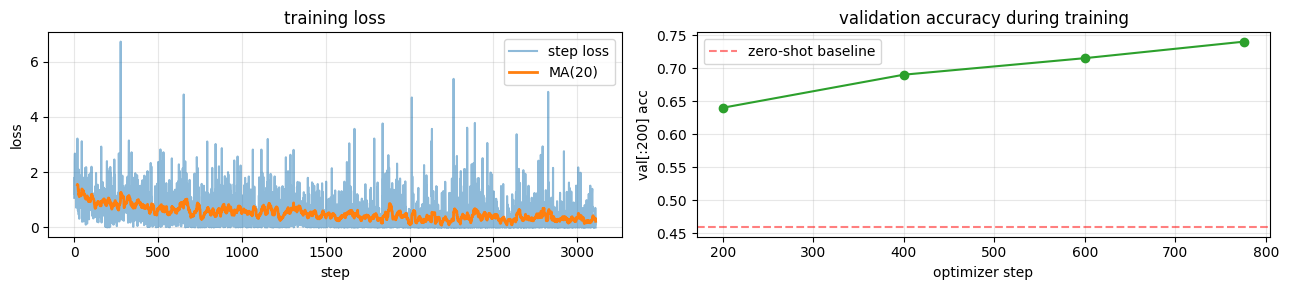

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 3))

# 左: loss
axes[0].plot(loss_history, alpha=0.5, label='step loss')
# 滑动平均
window = 20
if len(loss_history) > window:
    smoothed = np.convolve(loss_history, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(loss_history)), smoothed, label=f'MA({window})', linewidth=2)
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss"); axes[0].set_title("training loss")
axes[0].grid(alpha=0.3); axes[0].legend()

# 右: val acc 曲线
if eval_history:
    steps, accs = zip(*eval_history)
    axes[1].plot(steps, accs, 'o-', color='C2')
    axes[1].axhline(0.459, color='red', linestyle='--', alpha=0.5, label='zero-shot baseline')
    axes[1].set_xlabel("optimizer step"); axes[1].set_ylabel("val[:200] acc")
    axes[1].set_title("validation accuracy during training")
    axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

## 10. Post-training eval on val


In [17]:
# 加载训练过程中 val[:200] 表现最好的 adapter
from peft import PeftModel

print(f"Loading best adapter from step {best_step} (val[:200] acc={best_acc:.4f})")
# best 已经在内存里, 但 save_pretrained 后内存里的状态可能被后续 step 改了
# 重新 load 一次确保是 best 那个
model.load_adapter(str(best_adapter_path), adapter_name="default")
print("✅ Best adapter loaded")

Loading best adapter from step 776 (val[:200] acc=0.7400)
✅ Best adapter loaded


In [18]:
model.eval()
model.gradient_checkpointing_disable()

# 先 sanity 200 条
val_sample = val_df.head(200).reset_index(drop=True)
preds_post = score_batch(model, processor, val_sample, IMAGE_ROOT, desc="post-train val[:200]")
acc_post = (np.array(preds_post) == val_sample["answer"].values).mean()
print(f"After training, val[:200] acc: {acc_post:.4f}")

post-train val[:200]:   0%|          | 0/200 [00:00<?, ?it/s]

After training, val[:200] acc: 0.7400


In [19]:
# 全量 val
RUN_FULL_VAL_POST = True
if RUN_FULL_VAL_POST:
    val_preds_post = score_batch(model, processor, val_df, IMAGE_ROOT, desc="post-train full val")
    val_acc_post = (np.array(val_preds_post) == val_df["answer"].values).mean()
    print(f"\n>>> Full val accuracy after training: {val_acc_post:.4f} <<<")
    if RUN_FULL_ZEROSHOT:
        print(f"    Zero-shot was: {val_acc_zs:.4f}")
        print(f"    Δ = {(val_acc_post - val_acc_zs)*100:+.2f} pp")

post-train full val:   0%|          | 0/1048 [00:00<?, ?it/s]


>>> Full val accuracy after training: 0.7815 <<<
    Zero-shot was: 0.4590
    Δ = +32.25 pp


## 11. Generate submission.csv

In [20]:
test_preds = score_batch(model, processor, test_df, IMAGE_ROOT, desc="test inference")

submission = pd.DataFrame({
    "id": test_df["id"].values,
    "answer": test_preds,
})

# 校验格式
assert len(submission) == len(test_df)
assert submission["answer"].dtype.kind in "iu"
assert (submission["answer"] >= 0).all()
for i, row in submission.head(10).iterrows():
    nc = test_df.loc[i, "num_choices"]
    assert row["answer"] < nc, f"row {i}: answer {row['answer']} >= num_choices {nc}"

submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"✅ Saved: {submission_path}")
print(submission.head())
print(f"\n答案分布:\n{submission['answer'].value_counts().sort_index()}")

test inference:   0%|          | 0/1008 [00:00<?, ?it/s]

✅ Saved: /content/outputs/submission.csv
           id  answer
0  test_01750       2
1  test_00128       0
2  test_02891       3
3  test_02425       3
4  test_00930       2

答案分布:
answer
0    367
1    337
2    225
3     79
Name: count, dtype: int64


In [21]:
# Save LoRA adapter (后面继续训用)
adapter_path = OUTPUT_DIR / "lora_adapter"
model.save_pretrained(adapter_path)
print(f"✅ Adapter saved to: {adapter_path}")

✅ Adapter saved to: /content/outputs/lora_adapter


In [22]:
print("=== 真实分布对比 ===")
print("\nTrain 真实 answer 分布:")
print(train_df['answer'].value_counts().sort_index())
print(f"\n各 num_choices 占比 (test):")
print(test_df['num_choices'].value_counts().sort_index())
print(f"\n各 num_choices 占比 (train):")
print(train_df['num_choices'].value_counts().sort_index())

=== 真实分布对比 ===

Train 真实 answer 分布:
answer
0    1124
1    1028
2     737
3     204
4      16
Name: count, dtype: int64

各 num_choices 占比 (test):
num_choices
2    272
3    438
4    260
5     38
Name: count, dtype: int64

各 num_choices 占比 (train):
num_choices
2     664
3    1552
4     783
5     110
Name: count, dtype: int64


In [ ]:
# ============ 过夜 TTA + 自动打包下载 ============
import os, pickle, shutil, itertools
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import torch

# ====== 0. 状态确认 ======
print("=" * 60)
print("Pre-flight check")
print("=" * 60)
assert "model" in dir(), "model 不在 namespace 里, 先把前面 cell 重跑一遍"
assert "processor" in dir(), "processor 不在"
assert "val_df" in dir() and "test_df" in dir(), "数据没加载"
assert "letter_token_ids" in dir(), "letter_token_ids 没生成"
assert "build_prompt" in dir(), "build_prompt 没定义"
assert "IMAGE_ROOT" in dir(), "IMAGE_ROOT 没定义"

model.eval()
if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()
print(f"✅ Model ready, device={model.device}")
print(f"✅ Val: {len(val_df)}, Test: {len(test_df)}")

# 准备输出目录
RUN_DIR = OUTPUT_DIR / "overnight_tta"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"✅ Output dir: {RUN_DIR}")


# ====== 1. Multi-resolution scoring ======
@torch.inference_mode()
def score_batch_multires(df, data_dir, sizes=(384, 448, 512), desc="multires"):
    """每张图在多个分辨率下推理, logits 平均后再 argmax. 返回 preds + 每条样本的归一 logit 向量."""
    preds, all_logits = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        nc = int(row["num_choices"])
        img_raw = Image.open(data_dir / row["image_path"]).convert("RGB")
        prompt = build_prompt(row, include_answer=False)
        avg = np.zeros(nc)
        for s in sizes:
            img = img_raw.resize((s, s), Image.BICUBIC)
            inputs = processor(text=[prompt], images=[img], return_tensors="pt")
            inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}
            out = model(**inputs)
            nl = out.logits[0, -1, :]
            for i in range(nc):
                avg[i] += nl[letter_token_ids[CHOICE_LETTERS[i]]].item()
        avg /= len(sizes)
        preds.append(int(np.argmax(avg)))
        all_logits.append(avg)
    return preds, all_logits


# ====== 2. Choice permutation scoring ======
@torch.inference_mode()
def score_batch_perm(df, data_dir, n_perms=4, img_size=384, desc="perm"):
    """选项随机重排 N 次, logits 映射回原 index 累加."""
    preds, all_logits = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        nc = int(row["num_choices"])
        original_choices = row["choices"]
        # 准备排列(用 row id 当 seed 保证可复现)
        seed = abs(hash(str(row.get("id", row.name)))) % (2**31)
        rng = np.random.default_rng(seed)
        if nc <= 4:
            all_perms = list(itertools.permutations(range(nc)))
            if len(all_perms) > n_perms:
                idxs = rng.choice(len(all_perms), n_perms, replace=False)
                perms = [all_perms[i] for i in idxs]
            else:
                perms = all_perms
        else:
            perms = [tuple(rng.permutation(nc)) for _ in range(n_perms)]

        img = Image.open(data_dir / row["image_path"]).convert("RGB").resize((img_size, img_size), Image.BICUBIC)
        accum = np.zeros(nc)
        for perm in perms:
            permuted_row = row.copy()
            permuted_row["choices"] = [original_choices[i] for i in perm]
            prompt = build_prompt(permuted_row, include_answer=False)
            inputs = processor(text=[prompt], images=[img], return_tensors="pt")
            inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}
            out = model(**inputs)
            nl = out.logits[0, -1, :]
            # letter k 的 logit 累加到原 index perm[k]
            for k in range(nc):
                original_idx = perm[k]
                accum[original_idx] += nl[letter_token_ids[CHOICE_LETTERS[k]]].item()
        accum /= len(perms)
        preds.append(int(np.argmax(accum)))
        all_logits.append(accum)
    return preds, all_logits


# ====== 3. 跑 val (做对比, 写 report 用) ======
print("\n" + "=" * 60)
print("VAL: Multi-resolution TTA")
print("=" * 60)
val_preds_mr, val_logits_mr = score_batch_multires(val_df, IMAGE_ROOT, sizes=(384, 448, 512), desc="val multires")
val_acc_mr = (np.array(val_preds_mr) == val_df["answer"].values).mean()
print(f">>> val multi-res acc: {val_acc_mr:.4f} (baseline 0.7844)")

with open(RUN_DIR / "val_multires.pkl", "wb") as f:
    pickle.dump({"preds": val_preds_mr, "logits": val_logits_mr, "acc": val_acc_mr}, f)

print("\n" + "=" * 60)
print("VAL: Choice permutation TTA")
print("=" * 60)
val_preds_perm, val_logits_perm = score_batch_perm(val_df, IMAGE_ROOT, n_perms=4, desc="val perm")
val_acc_perm = (np.array(val_preds_perm) == val_df["answer"].values).mean()
print(f">>> val perm acc: {val_acc_perm:.4f} (baseline 0.7844)")

with open(RUN_DIR / "val_perm.pkl", "wb") as f:
    pickle.dump({"preds": val_preds_perm, "logits": val_logits_perm, "acc": val_acc_perm}, f)

# Combined val
val_preds_comb = []
for i in range(len(val_df)):
    nc = int(val_df.iloc[i]["num_choices"])
    combined = np.array(val_logits_mr[i][:nc]) + np.array(val_logits_perm[i][:nc])
    val_preds_comb.append(int(np.argmax(combined)))
val_acc_comb = (np.array(val_preds_comb) == val_df["answer"].values).mean()
print(f"\n>>> val COMBINED (mr + perm) acc: {val_acc_comb:.4f}")

with open(RUN_DIR / "val_combined.pkl", "wb") as f:
    pickle.dump({"preds": val_preds_comb, "acc": val_acc_comb}, f)


# ====== 4. 跑 test (生成各种 submission) ======
print("\n" + "=" * 60)
print("TEST: Multi-resolution TTA")
print("=" * 60)
test_preds_mr, test_logits_mr = score_batch_multires(test_df, IMAGE_ROOT, sizes=(384, 448, 512), desc="test multires")
with open(RUN_DIR / "test_multires.pkl", "wb") as f:
    pickle.dump({"preds": test_preds_mr, "logits": test_logits_mr}, f)
sub_mr = pd.DataFrame({"id": test_df["id"].values, "answer": test_preds_mr})
sub_mr.to_csv(RUN_DIR / "submission_multires.csv", index=False)

print("\n" + "=" * 60)
print("TEST: Choice permutation TTA")
print("=" * 60)
test_preds_perm, test_logits_perm = score_batch_perm(test_df, IMAGE_ROOT, n_perms=4, desc="test perm")
with open(RUN_DIR / "test_perm.pkl", "wb") as f:
    pickle.dump({"preds": test_preds_perm, "logits": test_logits_perm}, f)
sub_perm = pd.DataFrame({"id": test_df["id"].values, "answer": test_preds_perm})
sub_perm.to_csv(RUN_DIR / "submission_perm.csv", index=False)

# Combined test
test_preds_comb = []
for i in range(len(test_df)):
    nc = int(test_df.iloc[i]["num_choices"])
    combined = np.array(test_logits_mr[i][:nc]) + np.array(test_logits_perm[i][:nc])
    test_preds_comb.append(int(np.argmax(combined)))
sub_comb = pd.DataFrame({"id": test_df["id"].values, "answer": test_preds_comb})
sub_comb.to_csv(RUN_DIR / "submission_combined.csv", index=False)


# ====== 5. 总结 ======
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
summary = f"""
方法                          | Val Acc
------------------------------|--------
Single-shot baseline (你的 best) | 0.7844
Multi-resolution TTA          | {val_acc_mr:.4f}
Choice permutation TTA        | {val_acc_perm:.4f}
Combined (mr + perm)          | {val_acc_comb:.4f}
"""
print(summary)
with open(RUN_DIR / "summary.txt", "w") as f:
    f.write(summary)


# ====== 6. 复制 best adapter 到 RUN_DIR(以防过期丢失) ======
print("\nCopying adapter for safekeeping...")
adapter_backup = RUN_DIR / "lora_best_backup"
if adapter_backup.exists():
    shutil.rmtree(adapter_backup)
shutil.copytree(best_adapter_path, adapter_backup)
print(f"✅ Adapter copied to {adapter_backup}")


# ====== 7. 打包所有产物 ======
print("\nPacking all artifacts...")
zip_path = "/content/overnight_results"
if os.path.exists(f"{zip_path}.zip"):
    os.remove(f"{zip_path}.zip")
shutil.make_archive(zip_path, "zip", str(RUN_DIR))
zip_size_mb = os.path.getsize(f"{zip_path}.zip") / 1e6
print(f"✅ Zip created: {zip_path}.zip ({zip_size_mb:.1f} MB)")


# ====== 8. 自动下载 ======
print("\n📥 Triggering download...")
try:
    from google.colab import files
    files.download(f"{zip_path}.zip")
    print("✅ Download triggered.")
except Exception as e:
    print(f"⚠️ 自动下载失败: {e}")

print("\n" + "=" * 60)
print("=" * 60)

Pre-flight check
✅ Model ready, device=cuda:0
✅ Val: 1048, Test: 1008
✅ Output dir: /content/outputs/overnight_tta

VAL: Multi-resolution TTA


val multires:   0%|          | 0/1048 [00:00<?, ?it/s]

>>> val multi-res acc: 0.7767 (baseline 0.7844)

VAL: Choice permutation TTA


val perm:   0%|          | 0/1048 [00:00<?, ?it/s]

>>> val perm acc: 0.7844 (baseline 0.7844)

>>> val COMBINED (mr + perm) acc: 0.7929

TEST: Multi-resolution TTA


...

test perm:   0%|          | 0/1008 [00:00<?, ?it/s]


SUMMARY

方法                          | Val Acc
------------------------------|--------
Single-shot baseline (你的 best) | 0.7844
Multi-resolution TTA          | 0.7767
Choice permutation TTA        | 0.7844
Combined (mr + perm)          | 0.7929


Copying adapter for safekeeping...
✅ Adapter copied to /content/outputs/overnight_tta/lora_best_backup

Packing all artifacts...
✅ Zip created: /content/overnight_results.zip (17.8 MB)

📥 Triggering download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download triggered. 你睡醒后会在 Downloads 文件夹看到 overnight_results.zip

ALL DONE 🎉 可以去睡了
